# Infinite Data: Figures 6 And 7

This notebook reproduces Appendix Figures 6 and 7. The W&B tag is `ICLR-infinite-data`, and the selected run uses online sampling with the minimal architecture.


In [1]:
from analysis.utils import fetch_run_data, plot_combined_heads, plot_kl_divergence_simple, plot_val_loss_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
RUN_ID = "p6mze2ux"
ATTENTION_STEPS = [0, 270, 580, 1500]
DIVERGENCE_STEPS = [330, 580]
MAX_STEPS = 2000

run_data = fetch_run_data(RUN_ID, metrics=["val_loss"])
cfg = run_data["config"]
pd.DataFrame(
    [{
        "run_id": RUN_ID,
        "name": run_data["name"],
        "tag": "ICLR-infinite-data",
        "train_samples": cfg["dataset"]["number"]["train"],
        "architecture": "minimal transformer",
        "span_lengths": cfg["teacher"]["span_lengths"],
    }]
)


,run_id,name,tag,train_samples,architecture,span_lengths
0,p6mze2ux,wobbly-snowball-1731,ICLR-infinite-data,-3000,minimal transformer,"[2, 2, 2]"


## Figure 6: Attention With Online Sampling

Online sampling removes finite-dataset reuse, but the same competitive-to-cooperative attention transition remains.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


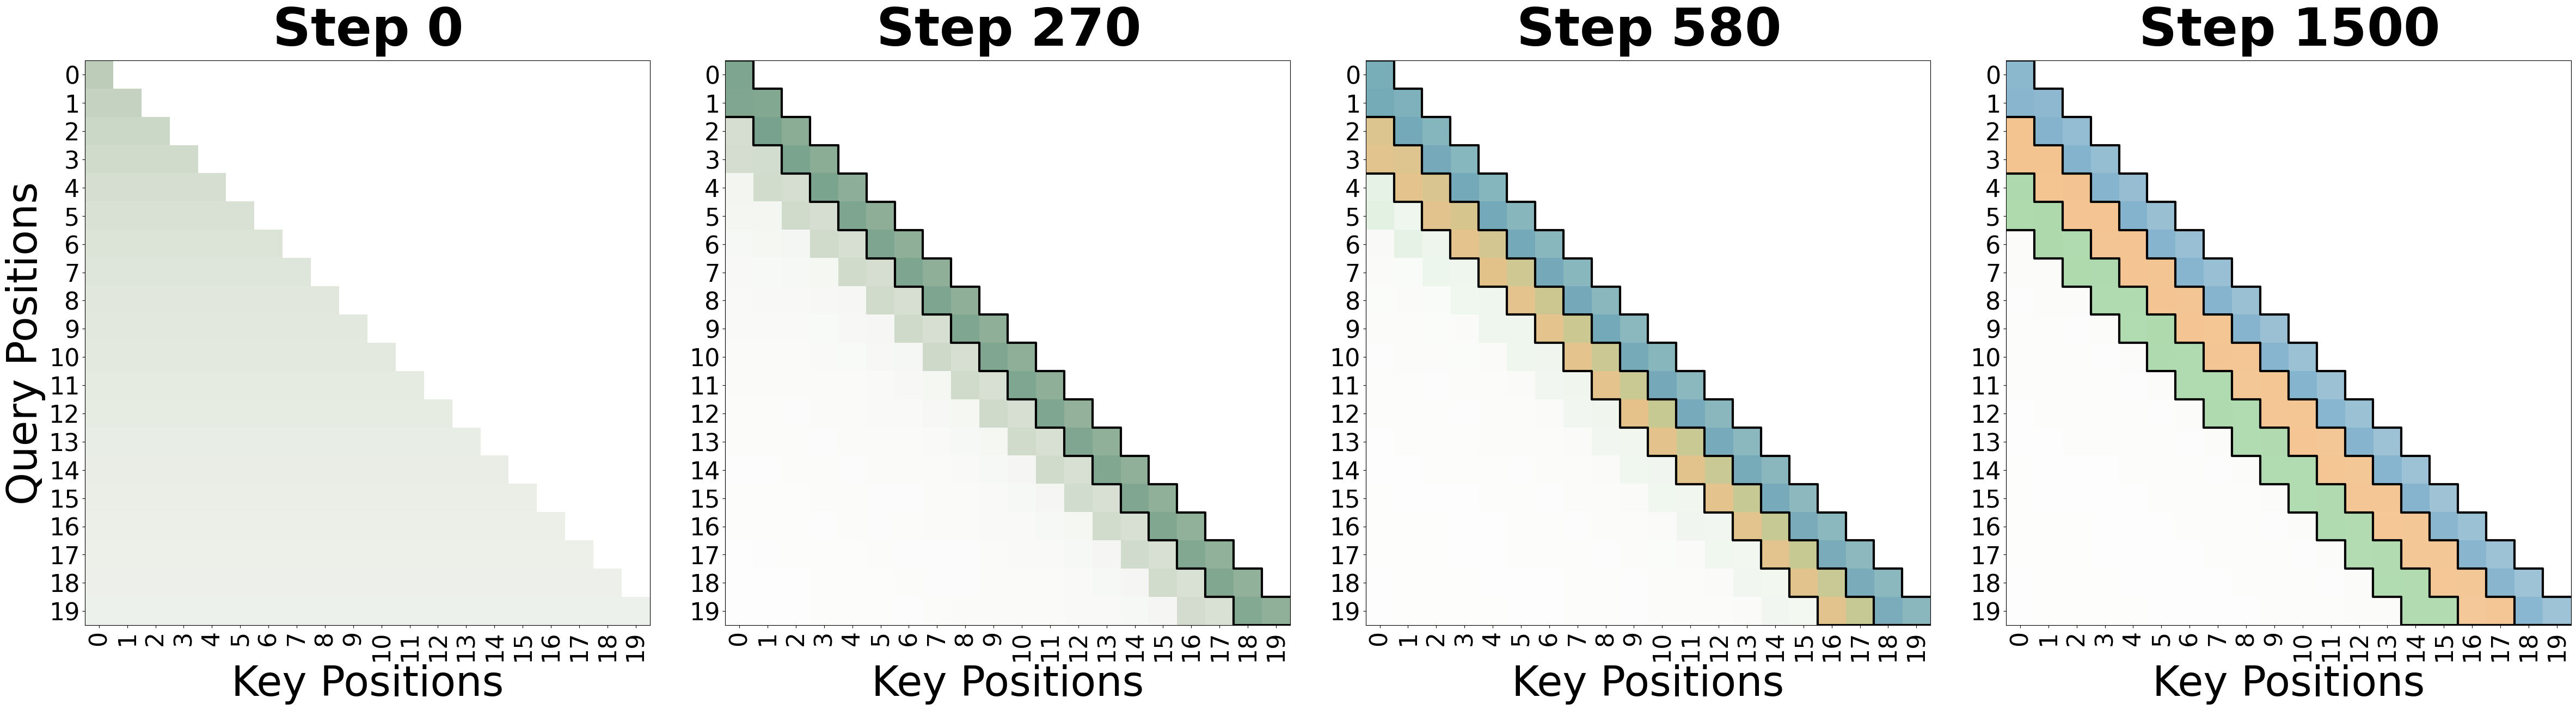

In [3]:
plot_combined_heads(
    RUN_ID,
    steps=ATTENTION_STEPS,
    split="val",
    head_colors=report_head_color_map([2, 0, 1]),
    staircases={1: [0, -2], 2: [0, -2, -4], 3: [0, -2, -4, -6]},
    save_name=output_path("attention-infinite-data"),
)


## Figure 7: Loss And KL With Online Sampling

The validation loss and KL curves retain the same staged drops, indicating the effect is not just memorization of a finite training set.


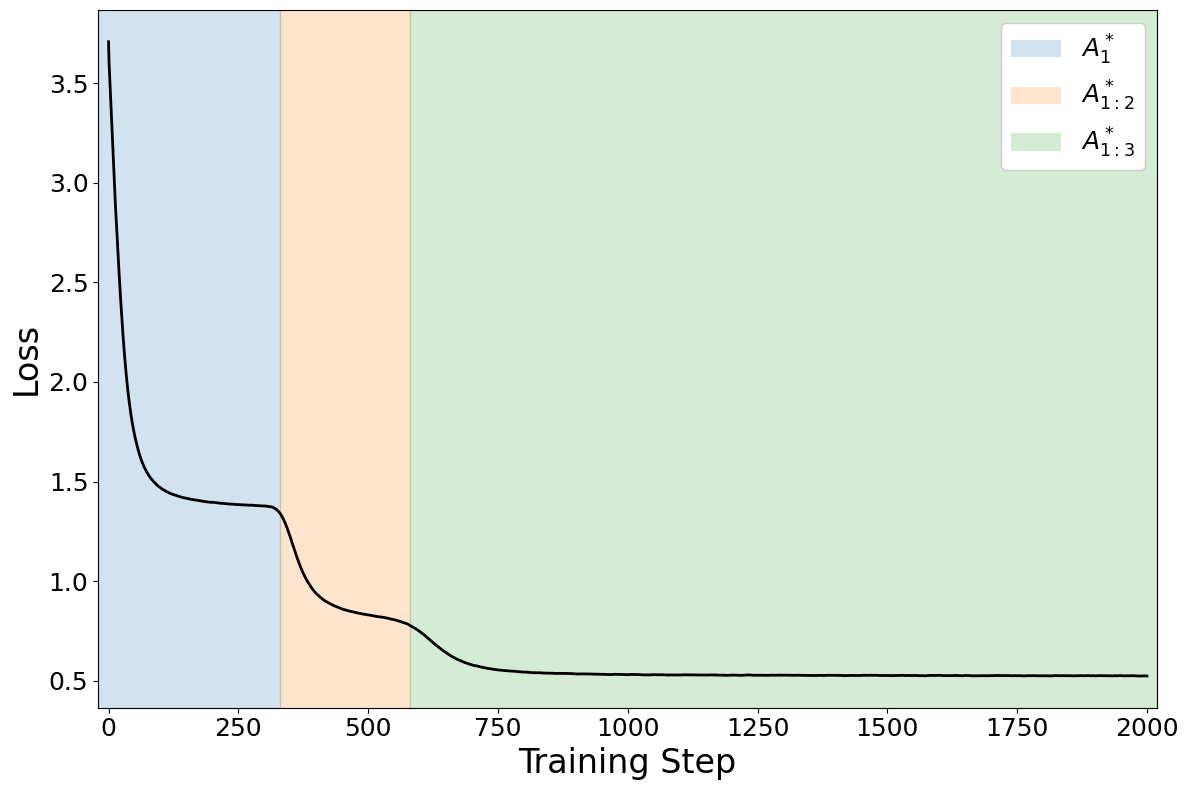

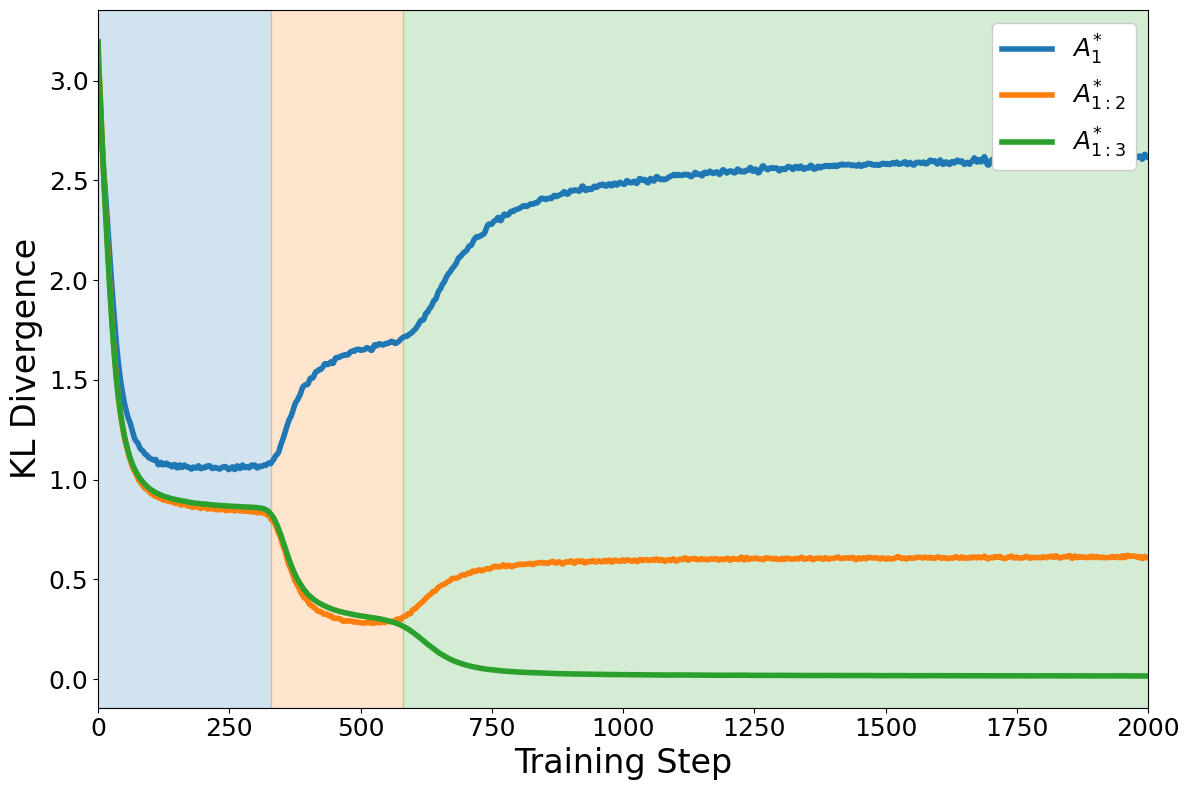

In [4]:
plot_val_loss_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    shift_steps=False,
    save_name=output_path("val-loss-infinite-data"),
)

plot_kl_divergence_simple(
    run_id=RUN_ID,
    divergence_steps=DIVERGENCE_STEPS,
    max_steps=MAX_STEPS,
    figsize=(12, 8),
    learnable=False,
    shift_steps=False,
    save_name=output_path("kl-infinite-data"),
)
